 WSD   min_lr  first_step  decay_start  final_train_100  final_val  final_ppl  best_val  best_val_step
  10 0.050000       12501        14025         3.308587   3.252561  25.856482  3.252561          15500
  20 0.050000       12501        12466         3.289499   3.233438  25.366730  3.233438          15500
  30 0.050000       10001        10908         3.282073   3.224984  25.153170  3.224984          15500
  10 0.100000           1        14025         3.316845   3.262342  26.110622  3.262342          15500
  20 0.100000       12501        12466         3.304524   3.248803  25.759485  3.248803          15500


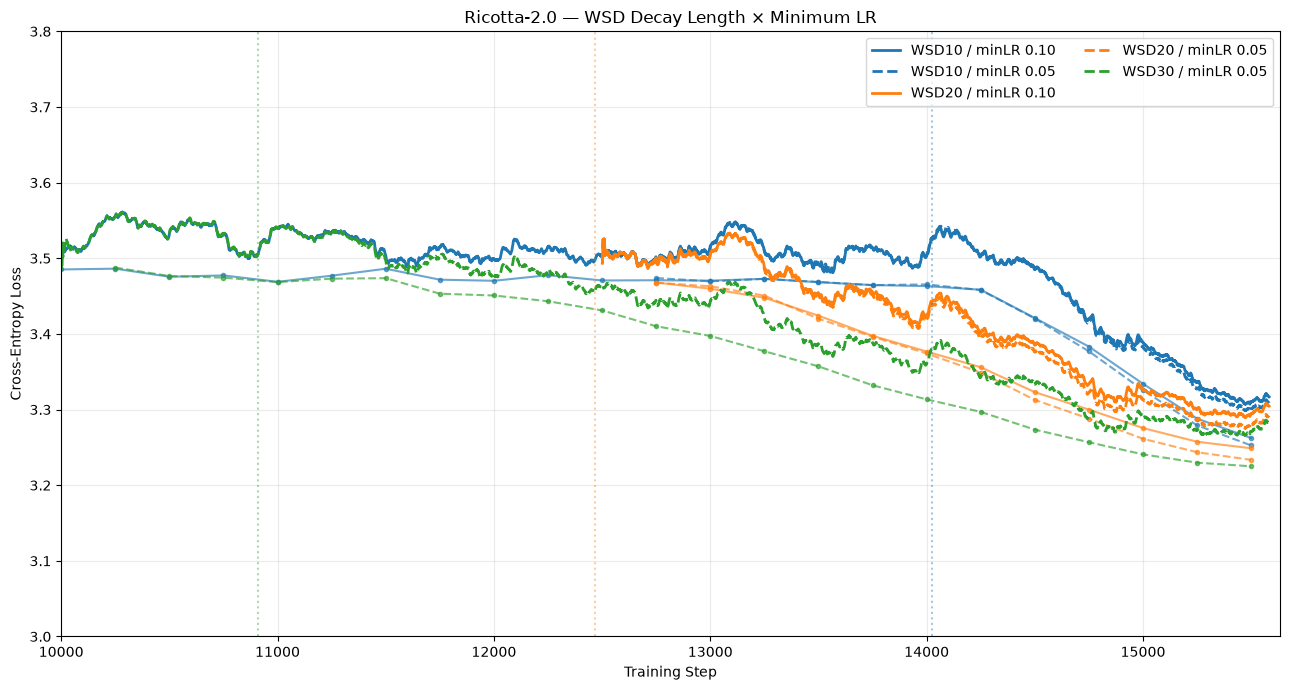

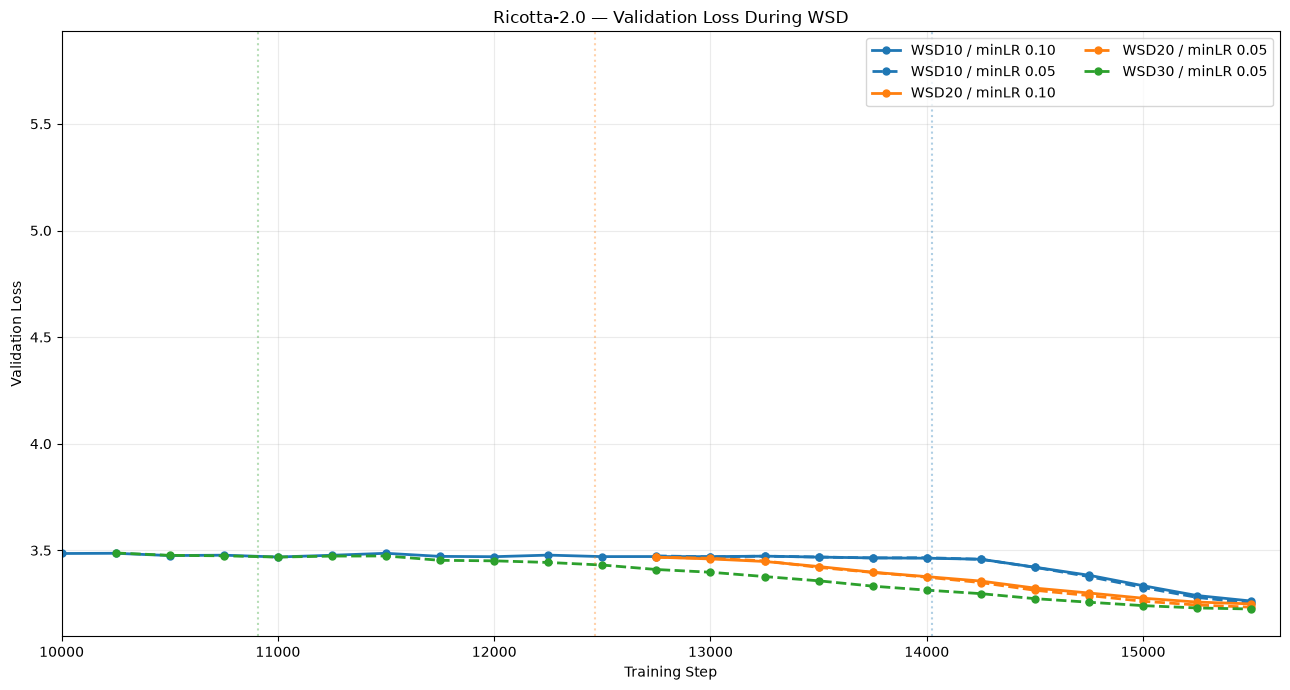

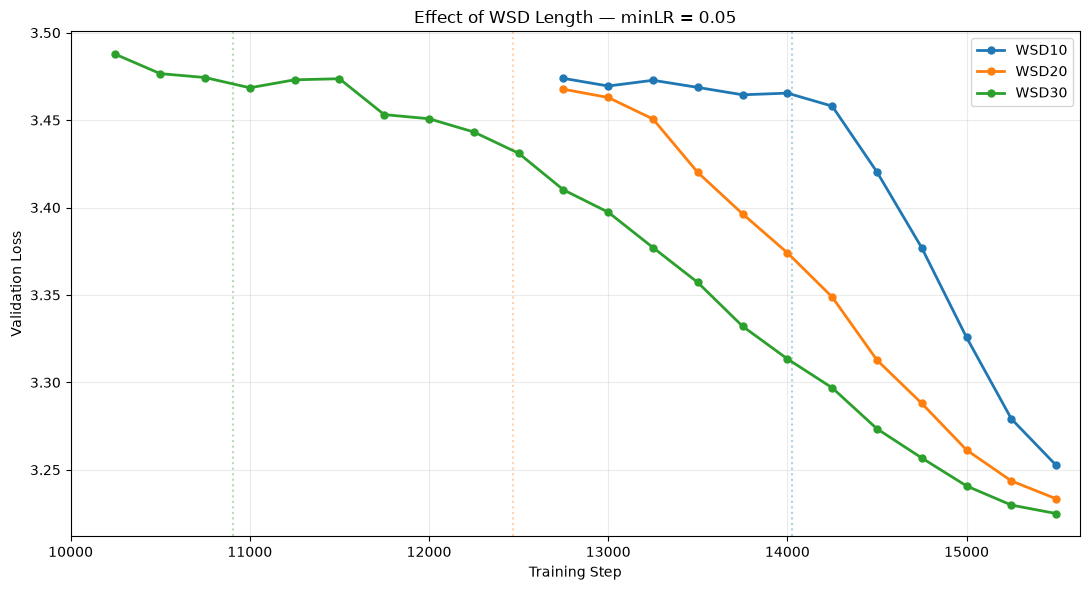

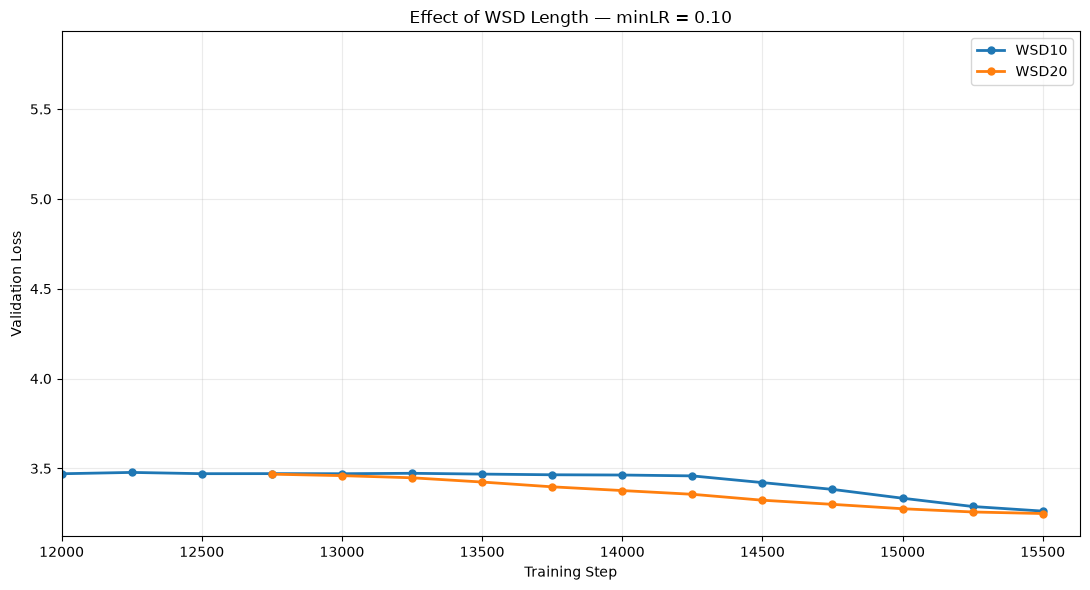

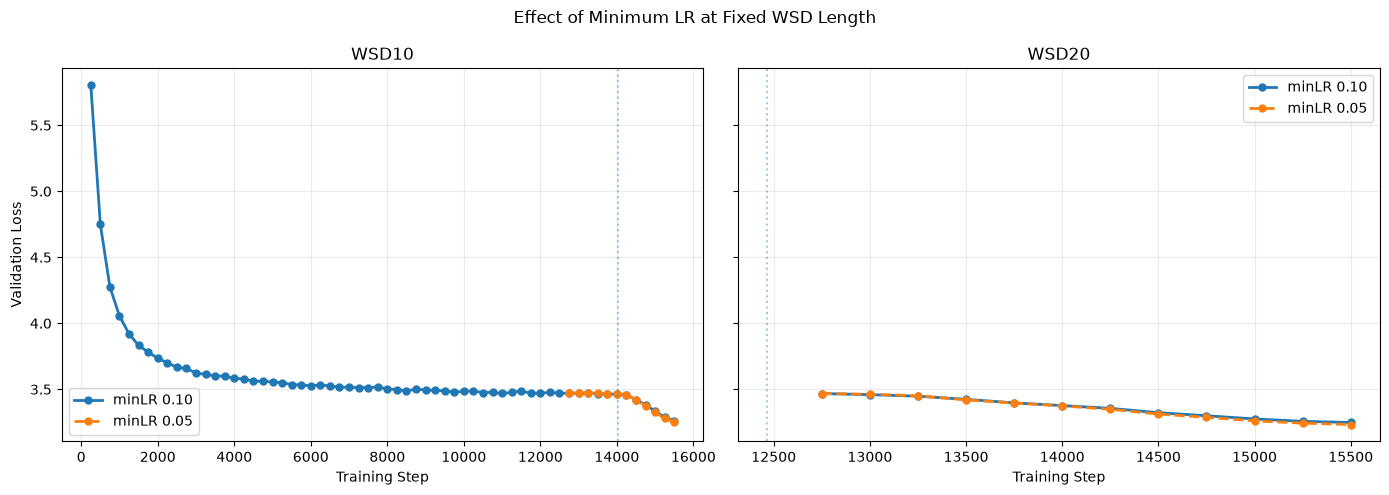

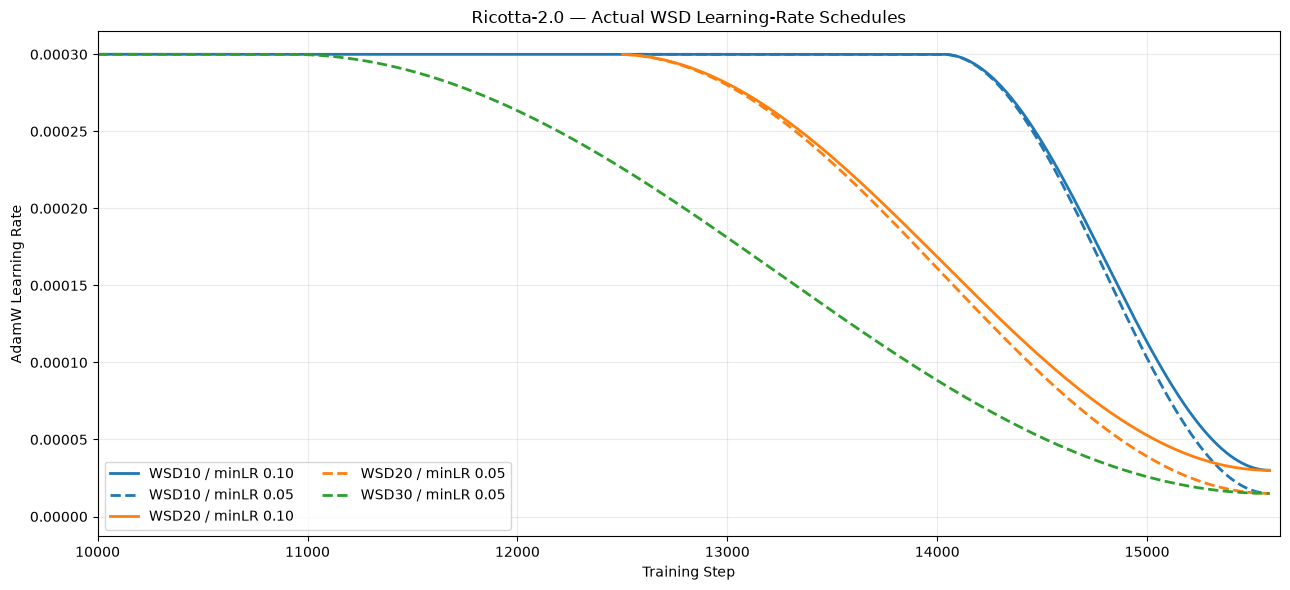

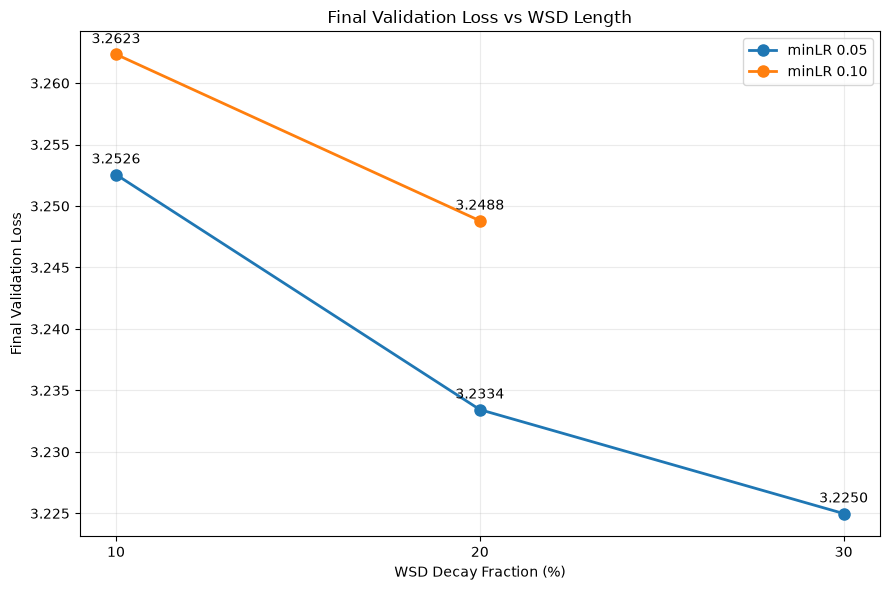

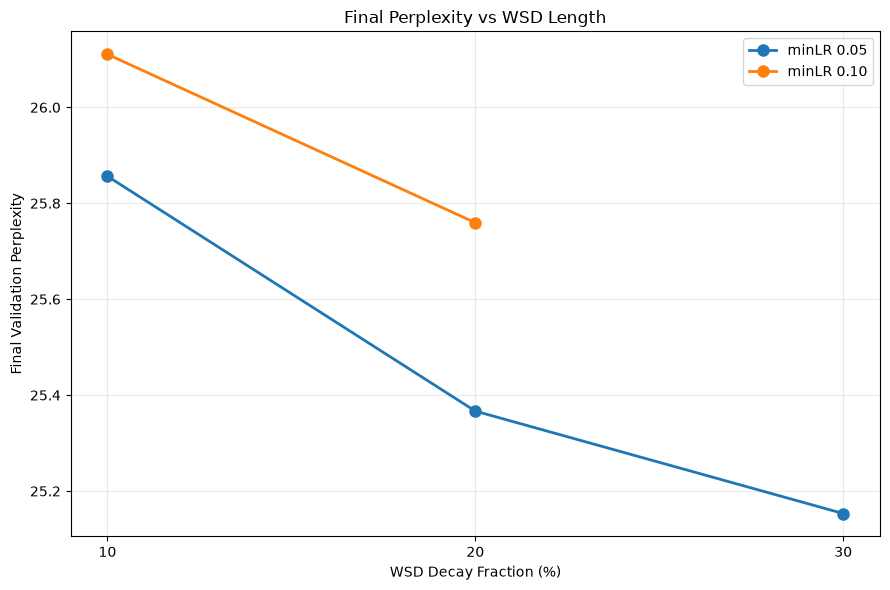

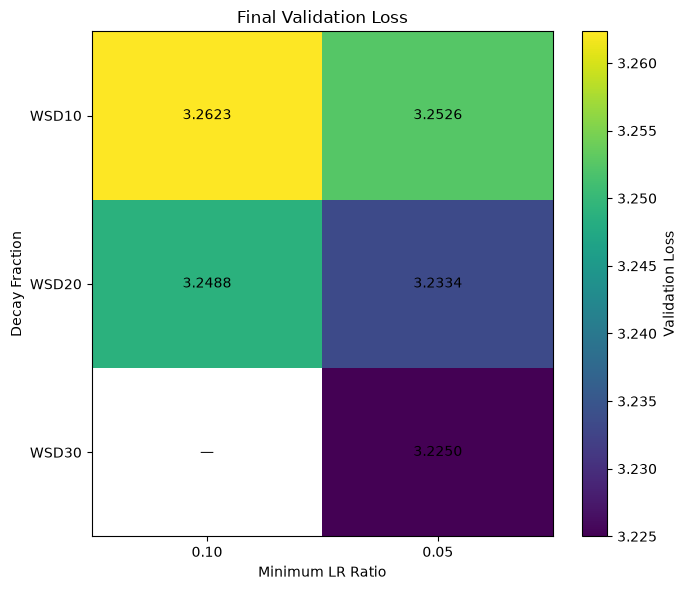

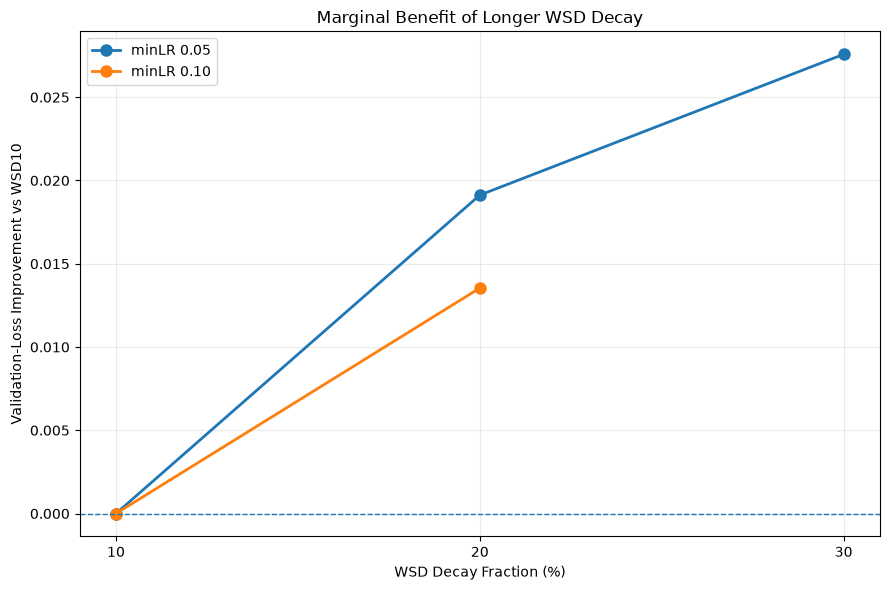

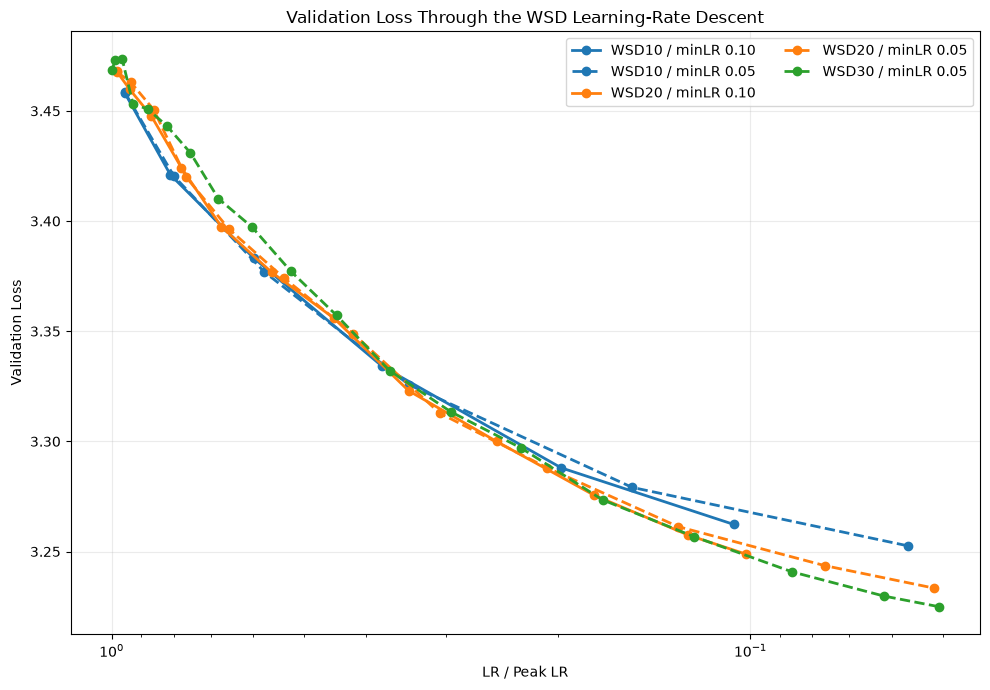

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re
from pathlib import Path

MAX_STEPS = 15_583
SMOOTH = 100

RUNS = {
    (10, 0.10): Path("runs/ricotta-2.0/r1-wsd10(minlr0.1)/ricotta_2_0/train.log"),
    (10, 0.05): Path("runs/ricotta-2.0/r1-wsd10(minlr0.05)/ricotta_2_0/train.log"),
    (20, 0.10): Path("runs/ricotta-2.0/r1-wsd20(minlr0.1)/ricotta_2_0/train.log"),
    (20, 0.05): Path("runs/ricotta-2.0/r1-wsd20(minlr0.05)/ricotta_2_0/train.log"),
    (30, 0.05): Path("runs/ricotta-2.0/r1-wsd30(minlr0.05)/ricotta_2_0/train.log"),
}

COLORS = {10: "C0", 20: "C1", 30: "C2"}
STYLES = {0.10: "-", 0.05: "--"}


def load_log(path):
    train_rows, val_rows = [], []

    with open(path, "r") as f:
        for line in f:
            parts = line.split()
            if len(parts) < 2 or not parts[0].isdigit():
                continue

            step = int(parts[0])
            kind = parts[1]

            values = {
                k: float(v)
                for k, v in re.findall(r"(\w+)=([\d.eE+-]+)", line)
            }

            if kind == "train":
                train_rows.append({"step": step, **values})
            elif kind == "val":
                val_rows.append({"step": step, **values})

    return pd.DataFrame(train_rows), pd.DataFrame(val_rows)


def decay_start(wsd):
    return MAX_STEPS * (1 - wsd / 100)


def label(wsd, min_lr):
    return f"WSD{wsd} / minLR {min_lr:.2f}"


def smooth(train, window=SMOOTH):
    return train["loss"].rolling(window, min_periods=1).mean()


runs = {
    key: dict(zip(("train", "val"), load_log(path)))
    for key, path in RUNS.items()
}


# Summary statistics

rows = []

for (wsd, min_lr), data in runs.items():
    train, val = data["train"], data["val"]

    best_idx = val["loss"].idxmin()
    final_val = val.iloc[-1]["loss"]

    rows.append({
        "WSD": wsd,
        "min_lr": min_lr,
        "first_step": int(train["step"].iloc[0]),
        "decay_start": int(round(decay_start(wsd))),
        "final_train_100": smooth(train).iloc[-1],
        "final_val": final_val,
        "final_ppl": np.exp(final_val),
        "best_val": val.loc[best_idx, "loss"],
        "best_val_step": int(val.loc[best_idx, "step"]),
    })

summary = pd.DataFrame(rows).sort_values(["min_lr", "WSD"])

print(summary.to_string(index=False, float_format=lambda x: f"{x:.6f}"))


# 1. All five runs — training + validation

fig, ax = plt.subplots(figsize=(13, 7))

for (wsd, min_lr), data in runs.items():
    train, val = data["train"], data["val"]
    c, ls = COLORS[wsd], STYLES[min_lr]

    ax.plot(
        train["step"], smooth(train),
        color=c, linestyle=ls, linewidth=2,
        label=label(wsd, min_lr),
    )

    ax.plot(
        val["step"], val["loss"],
        color=c, linestyle=ls,
        marker="o", markersize=3, alpha=0.65,
    )

for wsd in [10, 20, 30]:
    ax.axvline(
        decay_start(wsd),
        color=COLORS[wsd],
        linestyle=":",
        alpha=0.4,
    )

ax.set_xlim(10_000, MAX_STEPS + 50)
ax.set_ylim(3.0, 3.8)
ax.set_xlabel("Training Step")
ax.set_ylabel("Cross-Entropy Loss")
ax.set_title("Ricotta-2.0 — WSD Decay Length × Minimum LR")
ax.grid(True, alpha=0.25)
ax.legend(ncol=2)
plt.tight_layout()
plt.show()


# 2. Validation only — probably the most useful trajectory graph

fig, ax = plt.subplots(figsize=(13, 7))

for (wsd, min_lr), data in runs.items():
    val = data["val"]

    ax.plot(
        val["step"], val["loss"],
        color=COLORS[wsd],
        linestyle=STYLES[min_lr],
        marker="o",
        markersize=5,
        linewidth=2,
        label=label(wsd, min_lr),
    )

for wsd in [10, 20, 30]:
    ax.axvline(
        decay_start(wsd),
        color=COLORS[wsd],
        linestyle=":",
        alpha=0.35,
    )

ax.set_xlim(10_000, MAX_STEPS + 50)
ax.set_xlabel("Training Step")
ax.set_ylabel("Validation Loss")
ax.set_title("Ricotta-2.0 — Validation Loss During WSD")
ax.grid(True, alpha=0.25)
ax.legend(ncol=2)
plt.tight_layout()
plt.show()


# 3. Isolate WSD length at minLR 0.05
# This is the cleanest 10 vs 20 vs 30 comparison.

fig, ax = plt.subplots(figsize=(11, 6))

for wsd in [10, 20, 30]:
    val = runs[(wsd, 0.05)]["val"]

    ax.plot(
        val["step"], val["loss"],
        color=COLORS[wsd],
        marker="o",
        markersize=5,
        linewidth=2,
        label=f"WSD{wsd}",
    )

    ax.axvline(
        decay_start(wsd),
        color=COLORS[wsd],
        linestyle=":",
        alpha=0.35,
    )

ax.set_xlim(10_000, MAX_STEPS + 50)
ax.set_xlabel("Training Step")
ax.set_ylabel("Validation Loss")
ax.set_title("Effect of WSD Length — minLR = 0.05")
ax.grid(True, alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


# 4. Isolate WSD length at minLR 0.10
# Only WSD10 and WSD20 exist here.

fig, ax = plt.subplots(figsize=(11, 6))

for wsd in [10, 20]:
    val = runs[(wsd, 0.10)]["val"]

    ax.plot(
        val["step"], val["loss"],
        color=COLORS[wsd],
        marker="o",
        markersize=5,
        linewidth=2,
        label=f"WSD{wsd}",
    )

ax.set_xlim(12_000, MAX_STEPS + 50)
ax.set_xlabel("Training Step")
ax.set_ylabel("Validation Loss")
ax.set_title("Effect of WSD Length — minLR = 0.10")
ax.grid(True, alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


# 5. Isolate minimum-LR effect at WSD10 and WSD20

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, wsd in zip(axes, [10, 20]):
    for min_lr in [0.10, 0.05]:
        val = runs[(wsd, min_lr)]["val"]

        ax.plot(
            val["step"], val["loss"],
            linestyle=STYLES[min_lr],
            marker="o",
            markersize=5,
            linewidth=2,
            label=f"minLR {min_lr:.2f}",
        )

    ax.axvline(
        decay_start(wsd),
        linestyle=":",
        alpha=0.4,
    )

    ax.set_title(f"WSD{wsd}")
    ax.set_xlabel("Training Step")
    ax.grid(True, alpha=0.25)
    ax.legend()

axes[0].set_ylabel("Validation Loss")
fig.suptitle("Effect of Minimum LR at Fixed WSD Length")
plt.tight_layout()
plt.show()


# 6. Actual AdamW LR schedules

fig, ax = plt.subplots(figsize=(13, 6))

for (wsd, min_lr), data in runs.items():
    train = data["train"]

    if "lr" not in train.columns:
        continue

    ax.plot(
        train["step"], train["lr"],
        color=COLORS[wsd],
        linestyle=STYLES[min_lr],
        linewidth=2,
        label=label(wsd, min_lr),
    )

ax.set_xlim(10_000, MAX_STEPS + 50)
ax.set_xlabel("Training Step")
ax.set_ylabel("AdamW Learning Rate")
ax.set_title("Ricotta-2.0 — Actual WSD Learning-Rate Schedules")
ax.grid(True, alpha=0.25)
ax.legend(ncol=2)
plt.tight_layout()
plt.show()


# 7. Final validation loss vs WSD length

fig, ax = plt.subplots(figsize=(9, 6))

for min_lr in [0.05, 0.10]:
    sub = summary[summary["min_lr"] == min_lr].sort_values("WSD")

    ax.plot(
        sub["WSD"], sub["final_val"],
        marker="o",
        markersize=8,
        linewidth=2,
        label=f"minLR {min_lr:.2f}",
    )

    for _, row in sub.iterrows():
        ax.annotate(
            f"{row['final_val']:.4f}",
            (row["WSD"], row["final_val"]),
            xytext=(0, 8),
            textcoords="offset points",
            ha="center",
        )

ax.set_xticks([10, 20, 30])
ax.set_xlabel("WSD Decay Fraction (%)")
ax.set_ylabel("Final Validation Loss")
ax.set_title("Final Validation Loss vs WSD Length")
ax.grid(True, alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


# 8. Final perplexity

fig, ax = plt.subplots(figsize=(9, 6))

for min_lr in [0.05, 0.10]:
    sub = summary[summary["min_lr"] == min_lr].sort_values("WSD")

    ax.plot(
        sub["WSD"], sub["final_ppl"],
        marker="o",
        markersize=8,
        linewidth=2,
        label=f"minLR {min_lr:.2f}",
    )

ax.set_xticks([10, 20, 30])
ax.set_xlabel("WSD Decay Fraction (%)")
ax.set_ylabel("Final Validation Perplexity")
ax.set_title("Final Perplexity vs WSD Length")
ax.grid(True, alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


# 9. Endpoint matrix
# WSD30 / 0.10 intentionally left blank.

matrix = np.full((3, 2), np.nan)

for i, wsd in enumerate([10, 20, 30]):
    for j, min_lr in enumerate([0.10, 0.05]):
        match = summary[
            (summary["WSD"] == wsd) &
            (summary["min_lr"] == min_lr)
        ]

        if len(match):
            matrix[i, j] = match["final_val"].iloc[0]

fig, ax = plt.subplots(figsize=(7, 6))

masked = np.ma.masked_invalid(matrix)
im = ax.imshow(masked, aspect="auto")

ax.set_xticks([0, 1])
ax.set_xticklabels(["0.10", "0.05"])
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(["WSD10", "WSD20", "WSD30"])

ax.set_xlabel("Minimum LR Ratio")
ax.set_ylabel("Decay Fraction")
ax.set_title("Final Validation Loss")

for i in range(3):
    for j in range(2):
        if np.isfinite(matrix[i, j]):
            text = f"{matrix[i, j]:.4f}"
        else:
            text = "—"

        ax.text(j, i, text, ha="center", va="center")

fig.colorbar(im, ax=ax, label="Validation Loss")
plt.tight_layout()
plt.show()


# 10. Improvement over WSD10 at the same minLR

fig, ax = plt.subplots(figsize=(9, 6))

for min_lr in [0.05, 0.10]:
    sub = summary[summary["min_lr"] == min_lr].sort_values("WSD")

    baseline = sub[sub["WSD"] == 10]["final_val"].iloc[0]
    improvement = baseline - sub["final_val"]

    ax.plot(
        sub["WSD"], improvement,
        marker="o",
        markersize=8,
        linewidth=2,
        label=f"minLR {min_lr:.2f}",
    )

ax.axhline(0, linewidth=1, linestyle="--")
ax.set_xticks([10, 20, 30])
ax.set_xlabel("WSD Decay Fraction (%)")
ax.set_ylabel("Validation-Loss Improvement vs WSD10")
ax.set_title("Marginal Benefit of Longer WSD Decay")
ax.grid(True, alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


# 11. Loss vs normalized LR
# Shows whether pushing LR lower continues buying validation improvement.

fig, ax = plt.subplots(figsize=(10, 7))

for (wsd, min_lr), data in runs.items():
    train, val = data["train"], data["val"]

    if "lr" not in train.columns:
        continue

    peak_lr = train["lr"].max()

    lr_at_val = np.interp(
        val["step"],
        train["step"],
        train["lr"],
    ) / peak_lr

    mask = val["step"] >= decay_start(wsd)

    ax.plot(
        lr_at_val[mask],
        val.loc[mask, "loss"],
        color=COLORS[wsd],
        linestyle=STYLES[min_lr],
        marker="o",
        linewidth=2,
        label=label(wsd, min_lr),
    )

ax.set_xscale("log")
ax.invert_xaxis()
ax.set_xlabel("LR / Peak LR")
ax.set_ylabel("Validation Loss")
ax.set_title("Validation Loss Through the WSD Learning-Rate Descent")
ax.grid(True, alpha=0.25)
ax.legend(ncol=2)
plt.tight_layout()
plt.show()